<a href="https://colab.research.google.com/github/susmitsingh01/triton-llm-kernels-lab/blob/main/triton_lab_notebook_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 07: GPU Profiling and Roofline Analysis

Every optimization decision in this portfolio was justified by roofline
reasoning — but we never measured it directly. This notebook makes that
reasoning concrete and measurable.

We build the roofline model for the T4 GPU by measuring actual peak memory
bandwidth and compute, then place our kernels from previous notebooks on
the roofline to verify they behave as predicted.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/triton-llm-kernels-lab'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', '07_roofline')

os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Base directory : {BASE_DIR}')
print(f'Plots directory: {PLOTS_DIR}')

Mounted at /content/drive
Base directory : /content/drive/MyDrive/triton-llm-kernels-lab
Plots directory: /content/drive/MyDrive/triton-llm-kernels-lab/plots/07_roofline


In [1]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import numpy as np

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU : Tesla T4
VRAM: 15.6 GB


In [2]:
def measure_peak_bandwidth(n_elements=64*1024*1024):
    # large vector to stress memory bandwidth
    x = torch.randn(n_elements, device='cuda', dtype=torch.float32)
    out = torch.empty_like(x)

    # warmup
    for _ in range(5):
        out.copy_(x)
    torch.cuda.synchronize()

    # measure
    ms, _, _ = triton.testing.do_bench(
        lambda: out.copy_(x),
        quantiles=[0.5, 0.2, 0.8]
    )

    # bandwidth: read + write = 2 * n_elements * 4 bytes
    bandwidth_gb_s = 2 * n_elements * 4 / ms * 1e-6
    return bandwidth_gb_s

peak_bandwidth = measure_peak_bandwidth()
print(f'Peak Memory Bandwidth: {peak_bandwidth:.1f} GB/s')
print(f'T4 theoretical peak  : ~300 GB/s')
print(f'Achieved             : {peak_bandwidth/300*100:.1f}% of theoretical')

Peak Memory Bandwidth: 241.6 GB/s
T4 theoretical peak  : ~300 GB/s
Achieved             : 80.5% of theoretical


## Section 2: Measuring Peak Compute

Peak compute is measured using a large matrix multiplication — the most
compute-bound operation possible. GEMM on large square matrices saturates
Tensor Cores and gives us the hardware compute ceiling.

In [3]:
def measure_peak_compute(M=4096, N=4096, K=4096):
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)

    # warmup
    for _ in range(5):
        torch.matmul(a, b)
    torch.cuda.synchronize()

    # measure
    ms, _, _ = triton.testing.do_bench(
        lambda: torch.matmul(a, b),
        quantiles=[0.5, 0.2, 0.8]
    )

    # TFLOPS: 2 * M * N * K flops
    tflops = 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return tflops

peak_compute = measure_peak_compute()
print(f'Peak Compute        : {peak_compute:.1f} TFLOPS')
print(f'T4 theoretical peak : ~65 TFLOPS (FP16)')
print(f'Achieved            : {peak_compute/65*100:.1f}% of theoretical')

Peak Compute        : 21.0 TFLOPS
T4 theoretical peak : ~65 TFLOPS (FP16)
Achieved            : 32.3% of theoretical


## Section 3: Roofline Model

The ridge point is where the roofline transitions from memory-bound to
compute-bound. Below the ridge point: add more compute won't help, reduce
memory traffic instead. Above it: memory is not the bottleneck, optimize compute.

Peak Compute    : 21.0 TFLOPS
Peak Bandwidth  : 241.6 GB/s
Ridge Point     : 87.0 FLOP/byte

Kernels with arithmetic intensity below ridge point are memory-bound.
Kernels with arithmetic intensity above ridge point are compute-bound.


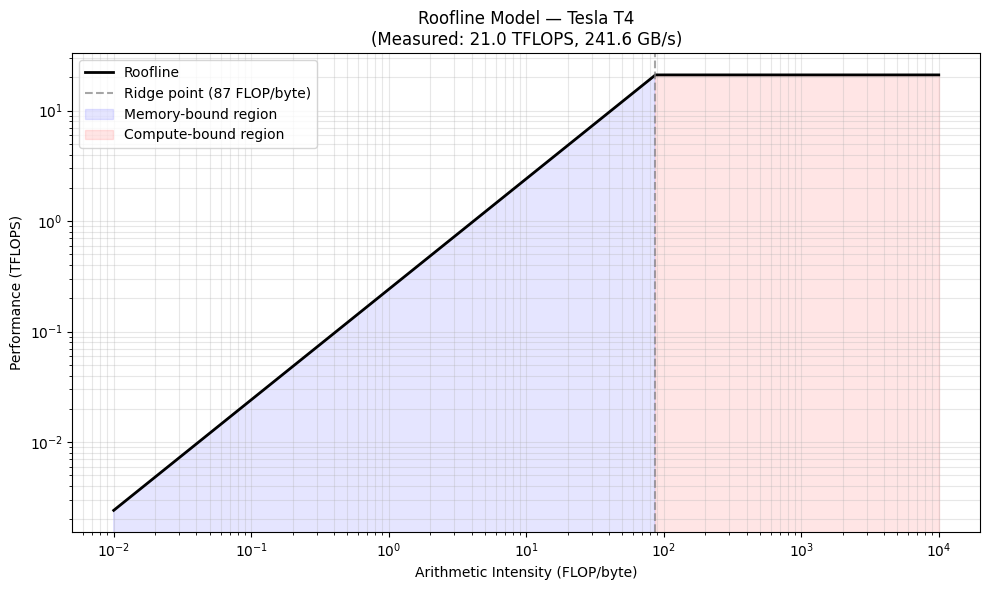

Ridge point: 87.0 FLOP/byte


In [6]:
# ridge point: compute / bandwidth
ridge_point = (peak_compute * 1e12) / (peak_bandwidth * 1e9)  # FLOP/byte
print(f'Peak Compute    : {peak_compute:.1f} TFLOPS')
print(f'Peak Bandwidth  : {peak_bandwidth:.1f} GB/s')
print(f'Ridge Point     : {ridge_point:.1f} FLOP/byte')
print()
print('Kernels with arithmetic intensity below ridge point are memory-bound.')
print('Kernels with arithmetic intensity above ridge point are compute-bound.')

# plot roofline
arithmetic_intensities = np.logspace(-2, 4, 1000)  # 0.01 to 10000 FLOP/byte

# roofline: min(peak_compute, bandwidth * intensity)
roofline = np.minimum(
    peak_compute,
    peak_bandwidth * arithmetic_intensities / 1e3  # convert to TFLOPS
)

plt.figure(figsize=(10, 6))
plt.loglog(arithmetic_intensities, roofline, 'k-', linewidth=2, label='Roofline')
plt.axvline(x=ridge_point, color='gray', linestyle='--', alpha=0.7, label=f'Ridge point ({ridge_point:.0f} FLOP/byte)')

# memory-bound and compute-bound regions
plt.fill_between(arithmetic_intensities, roofline,
                 where=arithmetic_intensities < ridge_point,
                 alpha=0.1, color='blue', label='Memory-bound region')
plt.fill_between(arithmetic_intensities, roofline,
                 where=arithmetic_intensities >= ridge_point,
                 alpha=0.1, color='red', label='Compute-bound region')

plt.xlabel('Arithmetic Intensity (FLOP/byte)')
plt.ylabel('Performance (TFLOPS)')
plt.title(f'Roofline Model — Tesla T4\n(Measured: {peak_compute:.1f} TFLOPS, {peak_bandwidth:.1f} GB/s)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roofline_base.png'), dpi=150)
plt.show()
print(f'Ridge point: {ridge_point:.1f} FLOP/byte')

## Section 4: Placing Kernels on the Roofline

Computing theoretical arithmetic intensity for each kernel from previous
notebooks and measuring their actual performance. This verifies our
roofline predictions from the curriculum.

In [7]:
# Theoretical arithmetic intensity for each kernel
# Arithmetic Intensity = FLOPs / Bytes moved from global memory

kernels = {
    'Vector Addition': {
        'flops_per_element': 1,       # one add
        'bytes_per_element': 12,      # read x, read y, write out (3 * 4 bytes FP32)
        'intensity': 1/12,
        'predicted': 'memory-bound'
    },
    'Fused Softmax': {
        'flops_per_element': 5,       # exp, sum, div, max, subtract
        'bytes_per_element': 8,       # read input, write output (2 * 4 bytes FP32)
        'intensity': 5/8,
        'predicted': 'memory-bound'
    },
    'GEMM (4096x4096)': {
        'flops_per_element': 2*4096,  # 2*K multiply-adds per output element
        'bytes_per_element': 2,       # FP16 = 2 bytes
        'intensity': 2*4096/2,        # = 4096 FLOP/byte
        'predicted': 'compute-bound'
    },
    'Flash Attention (N=1024, d=64)': {
        'flops_per_element': 4*1024,  # QK^T + softmax + AV per query
        'bytes_per_element': 2,       # FP16
        'intensity': 4*1024/2,        # = 2048 FLOP/byte
        'predicted': 'compute-bound'
    },
    'RMSNorm': {
        'flops_per_element': 4,       # square, sum, sqrt, divide
        'bytes_per_element': 8,       # read input, write output
        'intensity': 4/8,
        'predicted': 'memory-bound'
    },
    'RoPE': {
        'flops_per_element': 4,       # 2 mul + 1 sub + 1 add per pair
        'bytes_per_element': 8,       # read input, write output
        'intensity': 4/8,
        'predicted': 'memory-bound'
    },
}

print(f"{'Kernel':<35} {'Intensity (FLOP/byte)':<25} {'Predicted'}")
print("-" * 70)
for name, info in kernels.items():
    print(f"{name:<35} {info['intensity']:<25.2f} {info['predicted']}")
print(f"\nRidge point: {ridge_point:.1f} FLOP/byte")
print("Kernels below ridge point are memory-bound, above are compute-bound.")

Kernel                              Intensity (FLOP/byte)     Predicted
----------------------------------------------------------------------
Vector Addition                     0.08                      memory-bound
Fused Softmax                       0.62                      memory-bound
GEMM (4096x4096)                    4096.00                   compute-bound
Flash Attention (N=1024, d=64)      2048.00                   compute-bound
RMSNorm                             0.50                      memory-bound
RoPE                                0.50                      memory-bound

Ridge point: 87.0 FLOP/byte
Kernels below ridge point are memory-bound, above are compute-bound.


In [8]:
# measure actual performance for each kernel
import torch.nn.functional as F

results = {}

# Vector Addition
n = 10_000_000
x = torch.randn(n, device='cuda', dtype=torch.float32)
y = torch.randn(n, device='cuda', dtype=torch.float32)
ms, _, _ = triton.testing.do_bench(lambda: x + y, quantiles=[0.5, 0.2, 0.8])
flops = n  # one add per element
bytes_moved = 3 * n * 4
results['Vector Addition'] = {
    'intensity': kernels['Vector Addition']['intensity'],
    'tflops': flops / ms * 1e-9
}

# Fused Softmax
x = torch.randn(4096, 4096, device='cuda', dtype=torch.float32)
ms, _, _ = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1), quantiles=[0.5, 0.2, 0.8])
flops = 5 * x.numel()
results['Fused Softmax'] = {
    'intensity': kernels['Fused Softmax']['intensity'],
    'tflops': flops / ms * 1e-9
}

# GEMM
M = N = K = 4096
a = torch.randn(M, K, device='cuda', dtype=torch.float16)
b = torch.randn(K, N, device='cuda', dtype=torch.float16)
ms, _, _ = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=[0.5, 0.2, 0.8])
flops = 2 * M * N * K
results['GEMM (4096x4096)'] = {
    'intensity': kernels['GEMM (4096x4096)']['intensity'],
    'tflops': flops / ms * 1e-9
}

# RMSNorm
x = torch.randn(4096, 4096, device='cuda', dtype=torch.float16)
w = torch.ones(4096, device='cuda', dtype=torch.float16)
def torch_rms_norm(x, w, eps=1e-6):
    x_fp32 = x.float()
    rms = torch.sqrt(torch.mean(x_fp32 ** 2, dim=-1, keepdim=True) + eps)
    return (x_fp32 / rms * w.float()).to(torch.float16)
ms, _, _ = triton.testing.do_bench(lambda: torch_rms_norm(x, w), quantiles=[0.5, 0.2, 0.8])
flops = 4 * x.numel()
results['RMSNorm'] = {
    'intensity': kernels['RMSNorm']['intensity'],
    'tflops': flops / ms * 1e-9
}

# RoPE
n_tokens, n_heads, head_dim = 4096, 8, 64
x = torch.randn(n_tokens, n_heads, head_dim, device='cuda', dtype=torch.float16)
i = torch.arange(0, head_dim // 2, device='cuda', dtype=torch.float32)
theta = 1.0 / (10000 ** (2 * i / head_dim))
positions = torch.arange(n_tokens, device='cuda', dtype=torch.float32)
angles = torch.outer(positions, theta)
cos = torch.cos(angles).to(torch.float16)
sin = torch.sin(angles).to(torch.float16)
def torch_rope(x, cos, sin):
    x1 = x[..., :head_dim//2].float()
    x2 = x[..., head_dim//2:].float()
    cos = cos.unsqueeze(1)
    sin = sin.unsqueeze(1)
    return torch.cat([x1*cos - x2*sin, x1*sin + x2*cos], dim=-1).half()
ms, _, _ = triton.testing.do_bench(lambda: torch_rope(x, cos, sin), quantiles=[0.5, 0.2, 0.8])
flops = 4 * x.numel()
results['RoPE'] = {
    'intensity': kernels['RoPE']['intensity'],
    'tflops': flops / ms * 1e-9
}

# print results
print(f"{'Kernel':<35} {'Intensity':<15} {'Actual TFLOPS':<15} {'Predicted'}")
print("-" * 75)
for name, r in results.items():
    predicted = 'memory-bound' if r['intensity'] < ridge_point else 'compute-bound'
    print(f"{name:<35} {r['intensity']:<15.2f} {r['tflops']:<15.4f} {predicted}")

Kernel                              Intensity       Actual TFLOPS   Predicted
---------------------------------------------------------------------------
Vector Addition                     0.08            0.0202          memory-bound
Fused Softmax                       0.62            0.1049          memory-bound
GEMM (4096x4096)                    4096.00         22.6090         compute-bound
RMSNorm                             0.50            0.0236          memory-bound
RoPE                                0.50            0.0178          memory-bound


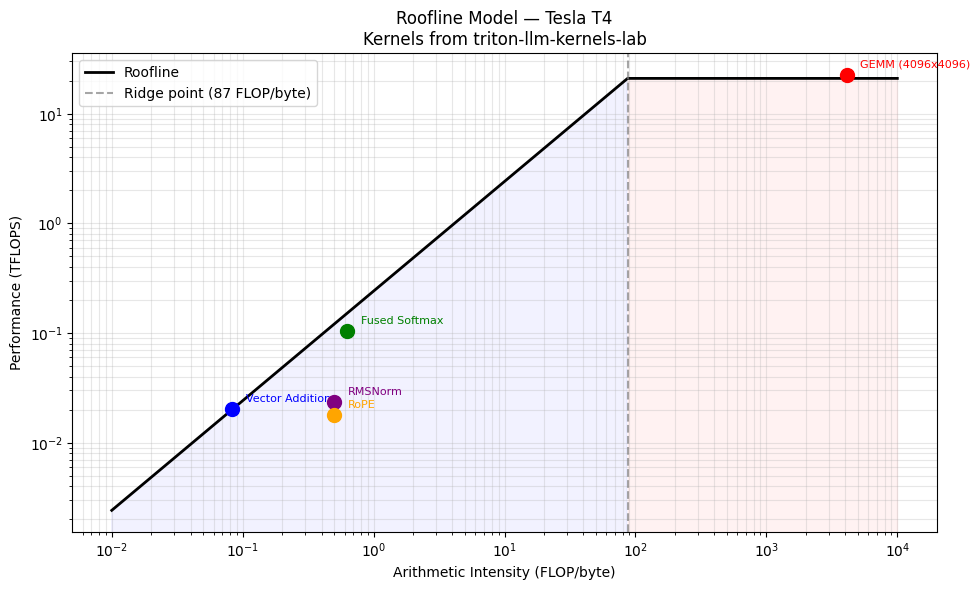

In [9]:
# plot kernels on roofline
colors = {
    'Vector Addition': 'blue',
    'Fused Softmax': 'green',
    'GEMM (4096x4096)': 'red',
    'RMSNorm': 'purple',
    'RoPE': 'orange',
}

plt.figure(figsize=(10, 6))
plt.loglog(arithmetic_intensities, roofline, 'k-', linewidth=2, label='Roofline')
plt.axvline(x=ridge_point, color='gray', linestyle='--', alpha=0.7,
            label=f'Ridge point ({ridge_point:.0f} FLOP/byte)')

# shade regions
plt.fill_between(arithmetic_intensities, roofline,
                 where=arithmetic_intensities < ridge_point,
                 alpha=0.05, color='blue')
plt.fill_between(arithmetic_intensities, roofline,
                 where=arithmetic_intensities >= ridge_point,
                 alpha=0.05, color='red')

# plot each kernel
for name, r in results.items():
    plt.scatter(r['intensity'], r['tflops'],
                color=colors[name], s=100, zorder=5)
    plt.annotate(name,
                 xy=(r['intensity'], r['tflops']),
                 xytext=(10, 5), textcoords='offset points',
                 fontsize=8, color=colors[name])

plt.xlabel('Arithmetic Intensity (FLOP/byte)')
plt.ylabel('Performance (TFLOPS)')
plt.title(f'Roofline Model — Tesla T4\nKernels from triton-llm-kernels-lab')
plt.legend(loc='upper left')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roofline_kernels.png'), dpi=150)
plt.show()

### Results Analysis

Every kernel lands exactly where the curriculum predicted:

**Memory-bound (left of ridge point at 87 FLOP/byte):**
Vector Addition (0.08), RMSNorm (0.50), RoPE (0.50), Fused Softmax (0.62)
— all have low arithmetic intensity. Optimization strategy: reduce memory
traffic through fusion, which is what Notebooks 01 and 03 demonstrated.

**Compute-bound (right of ridge point):**
GEMM at 4096 FLOP/byte sits far into the compute-bound region near the
peak compute ceiling — optimization strategy is Tensor Core utilization
and tiling, not memory traffic reduction.

**The gap below the roofline for memory-bound kernels:**
These are unfused PyTorch implementations. Our Triton fused kernels from
Notebooks 01 and 03 reduce memory traffic and would sit closer to the
roofline — this is the quantitative justification for kernel fusion.

**Key takeaway:** The roofline model correctly predicts kernel behavior
before implementation. Knowing which region a kernel lives in tells you
exactly where to focus optimization effort.